In [1]:
import numpy as np
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d as plt3d
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
from IPython.display import HTML
import matplotlib as mpl
import colorsys
from matplotlib.colors import to_rgb, to_hex

In [2]:
T = 1
mu_0, sig_0 = -25,1
mu_1, sig_1 = 20,5
N_particles = 3000
D = 1
dt = 0.01
num_steps = int(T/dt)
particles = np.zeros((N_particles,num_steps))
print(particles.shape)
particles[:,0] = np.random.randn(N_particles) * sig_0 + mu_0

t_space = np.linspace(0, T, num_steps)

for i in range(0, num_steps-1):

    t = t_space[i]
    tau = t / T
    time_left = max(T - t, 1e-5)
    
    # Theoretical bridge stats at time t
    mu_t = mu_0 + tau * (mu_1 - mu_0)
    var_t = (1 - tau) * sig_0**2 + tau * sig_1**2 + 2 * D * T * tau * (1 - tau)
    
    # Drift coefficients
    alpha_t = (sig_1**2 - var_t - 2 * D * time_left) / (2 * var_t * time_left)
    beta_t = (mu_1 - mu_t) / time_left - alpha_t * mu_t
    
    # Euler-Maruyama step
    current_x = particles[:,i]
    drift = alpha_t * current_x + beta_t
    diffusion = np.sqrt(2 * D * dt) * np.random.randn(N_particles)
    particles[:,i+1] = current_x + drift* dt + diffusion

(3000, 100)


19.368841581069237
4.658444807774523


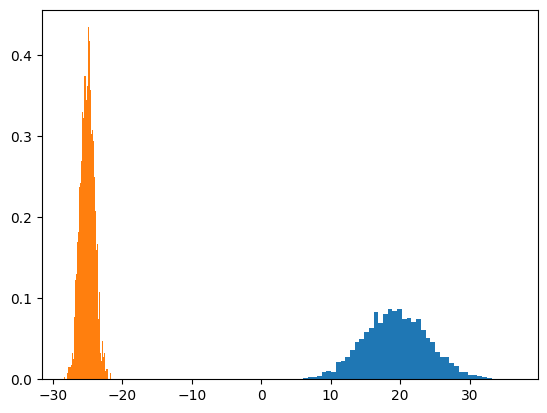

In [3]:
plt.hist(particles[:,-1],bins=50,  density=True)
plt.hist(particles[:,0],bins=50,  density=True)
print(np.mean(particles[:,-1]))
print(np.std(particles[:,-1]))

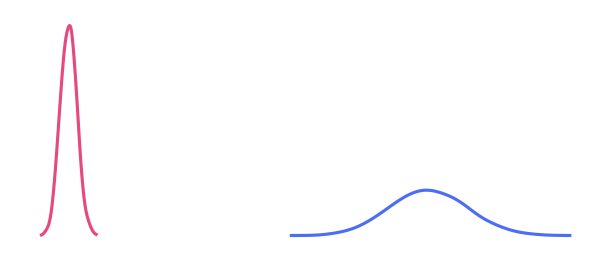

In [25]:
fig, ax = plt.subplots(figsize=(5, 2), dpi = 150)

ax.set_xticks([])
ax.set_xticklabels([])
ax.set_yticks([])
ax.set_yticklabels([])

data = particles[:,0]
vals, bin_edges= np.histogram(particles[:,0], bins=100)
bin_w = bin_edges[1] - bin_edges[0]
bin_centers = 0.5 * (bin_edges[0:-1] + bin_edges[1:])
vals = np.pad(vals, (1,1))
bin_centers = np.pad(bin_centers, (1,1), constant_values=(bin_centers[0]-bin_w, bin_centers[-1]+bin_w))
kde = gaussian_kde(data, bw_method=0.3)  # bw_method controls smoothness
pdf = kde(bin_centers)

line_1, = ax.plot(bin_centers, pdf, lw=1.5, color = '#e64980')
# fill_1 = ax.fill_between(bin_centers , pdf, 0, alpha = 0.6)

data = particles[:,-1]
vals, bin_edges= np.histogram(particles[:,-1], bins=100)
bin_w = bin_edges[1] - bin_edges[0]
bin_centers = 0.5 * (bin_edges[0:-1] + bin_edges[1:])
vals = np.pad(vals, (1,1))
bin_centers = np.pad(bin_centers, (1,1), constant_values=(bin_centers[0]-bin_w, bin_centers[-1]+bin_w))
kde = gaussian_kde(data, bw_method=0.3)  # bw_method controls smoothness
pdf = kde(bin_centers)

line_2, = ax.plot(bin_centers, pdf, lw=1.5, color = '#4c6ef5')
# fill_2 = ax.fill_between(bin_centers , pdf, 0, alpha = 0.6)

for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

line_, = ax.plot([],[])
fill_ =  ax.fill_between([],[],[])

def interpolate_color_hsv(c1, c2, t):
    """
    Interpolate between two colors in HSV space.
    c1, c2: any Matplotlib color format (name, hex, or RGB tuple)
    t: interpolation factor in [0, 1]
    """
    # Convert to RGB in [0,1]
    rgb1 = np.array(to_rgb(c1))
    rgb2 = np.array(to_rgb(c2))
    
    # Convert RGB -> HSV
    hsv1 = np.array(colorsys.rgb_to_hsv(*rgb1))
    hsv2 = np.array(colorsys.rgb_to_hsv(*rgb2))
    
    # Handle hue wrap-around (e.g., 350° to 10° should go through 0°)
    if abs(hsv1[0] - hsv2[0]) > 0.5:
        if hsv1[0] > hsv2[0]:
            hsv2[0] += 1.0
        else:
            hsv1[0] += 1.0
    
    # Interpolate HSV
    hsv_interp = (1 - t) * hsv1 + t * hsv2
    hsv_interp[0] = hsv_interp[0] % 1.0  # wrap hue back into [0,1]
    
    # Convert back to RGB
    rgb_interp = colorsys.hsv_to_rgb(*hsv_interp)
    return rgb_interp

In [26]:
fill_ = [None]  # Use a mutable container to keep reference

def update(frame):
    data = particles[:,frame]
    vals, bin_edges= np.histogram(data, bins=100)
    bin_w = bin_edges[1] - bin_edges[0]
    bin_centers = 0.5 * (bin_edges[0:-1] + bin_edges[1:])
    vals = np.pad(vals, (1,1))
    bin_centers = np.pad(bin_centers, (1,1), constant_values=(bin_centers[0]-bin_w, bin_centers[-1]+bin_w))
    kde = gaussian_kde(data, bw_method=0.3)
    pdf = kde(bin_centers)

    color = interpolate_color_hsv('#e64980', '#4c6ef5', frame/num_steps)
    line_.set_data(bin_centers, pdf)
    line_.set_color(color=color)

    # Remove previous fill if it exists
    if fill_[0] is not None:
        fill_[0].remove()
    # Create new fill
    fill_[0] = ax.fill_between(bin_centers, pdf, 0, alpha=0.7, color=color)

    return line_, fill_[0]

ani_1 = FuncAnimation(
    fig,
    update,
    frames=num_steps,
    interval=25,
    blit=False  # blit=True may not work with fill_between
)

In [29]:
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=30)
ani_1.save("bridge_anim.gif", writer=writer, dpi=150)
HTML(ani_1.to_jshtml())

In [57]:
fig, ax = plt.subplots(figsize=(5, 2), dpi = 150)
# mpl.rcParams.update(mpl.rcParamsDefault)
plt.rc("font", family="Inter")
plt.rc("xtick", labelsize="medium")
plt.rc("ytick", labelsize="medium")

t_array = np.linspace(0, 1, num_steps)
ax.set_xlim(t_array.min(), t_array.max())
ax.set_ylim(particles[:,0].min(), particles[:,-1].max())

def interpolate_color_hsv(c1, c2, t):
    """
    Interpolate between two colors in HSV space.
    c1, c2: any Matplotlib color format (name, hex, or RGB tuple)
    t: interpolation factor in [0, 1]
    """
    # Convert to RGB in [0,1]
    rgb1 = np.array(to_rgb(c1))
    rgb2 = np.array(to_rgb(c2))
    
    # Convert RGB -> HSV
    hsv1 = np.array(colorsys.rgb_to_hsv(*rgb1))
    hsv2 = np.array(colorsys.rgb_to_hsv(*rgb2))
    
    # Handle hue wrap-around (e.g., 350° to 10° should go through 0°)
    if abs(hsv1[0] - hsv2[0]) > 0.5:
        if hsv1[0] > hsv2[0]:
            hsv2[0] += 1.0
        else:
            hsv1[0] += 1.0
    
    # Interpolate HSV
    hsv_interp = (1 - t) * hsv1 + t * hsv2
    hsv_interp[0] = hsv_interp[0] % 1.0  # wrap hue back into [0,1]
    
    # Convert back to RGB
    rgb_interp = colorsys.hsv_to_rgb(*hsv_interp)
    return rgb_interp

lc = LineCollection([],cmap='plasma', linewidths=0.2, alpha=0.8)
ax.add_collection(lc)
ax.set_xlabel('Time')
ax.set_ylabel('Position')

def init():
    ax.set_xlabel('Time')
    ax.set_ylabel('Position')
    return lc, ax.xaxis.label, ax.yaxis.label

def update(frame):
    if frame < 2:   return lc, ax.xaxis.label, ax.yaxis.label
    
    # 2. Reshape into individual segments
    # For a gradient, each segment is a line between point (t, y) and (t+1, y+1)
    # Total segments = N_particles * (frame - 1)
    
    # Get x and y coords
    x = t_array[:frame]
    y = particles[::10, :frame]
    
    # Create segments: shape (N, frame-1, 2, 2)
    # Each segment is [[x_i, y_i], [x_i+1, y_i+1]]
    points = np.stack([np.broadcast_to(x, (N_particles//10, frame)), y], axis=-1)
    segments = np.concatenate([points[:, :-1, np.newaxis, :], 
                               points[:, 1:, np.newaxis, :]], axis=2)
    
    # Flatten N and Time dimensions so it's just a long list of segments
    segments = segments.reshape(-1, 2, 2)
    lc.set_segments(segments)
    
    # 3. Set the "array" which dictates the color based on the colormap
    # We want the color to depend on the time (the x-coordinate)
    # We repeat the time array for every particle
    color_values = np.tile(x[:-1], N_particles)
    lc.set_array(color_values)
    
    # Adjust color limits so the gradient scales with time
    lc.set_clim(t_array[0], t_array[-1])
    return lc, ax.xaxis.label, ax.yaxis.label

ani_2 = FuncAnimation(
    fig,
    update,
    frames= num_steps,
    interval=25,
    blit= False
)
fig.tight_layout()

In [58]:
writer = PillowWriter(fps=30)
ani_2.save("bridge_anim_sde.gif", writer=writer, dpi=150)

In [56]:
HTML(ani_2.to_jshtml())